# EDA: Who Owns
This EDA examines who owns residential property in Switzerland across generations:

* Silent Generation (<=1945)
* Babyboomers (1946-1964)
* Generation X (1965-1980)
* Millennials / Gen Y (1981-1996)
* Generation Z (1997-2012)

Data basis: four FSO (Federal Statistics Office) sources (2019–2024).

**Key Research Questions**

| # | Question |
|---|----------|
| 1 | Which generations dominate the Swiss population – and is this changing? |
| 2 | How much does the homeownership rate vary between cantons? (optional) |
| 3 | Which occupancy type dominates within each generation? |
| 4 | Do older generations have more living space per person? |
| 5 | Is the cantonal homeownership rate correlated with the share of older residents? |

## Imports & Konfiguration

In [16]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── Visual Set Up ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})

# ── Configuration ─────────────────────────────────────────────────
GEN_ORDER = [
    "Silent Generation (<=1945)",
    "Babyboomers (1946-1964)",
    "Generation X (1965-1980)",
    "Millennials / Gen Y (1981-1996)",
    "Generation Z (1997-2012)",
    "Ausserhalb Definition",
]
GEN_ORDER_PLOT = GEN_ORDER[:-1]          # ohne "Ausserhalb Definition"
GEN_PALETTE    = dict(zip(GEN_ORDER_PLOT, sns.color_palette("tab10", n_colors=len(GEN_ORDER_PLOT))))

# Bewohnertyp-Farben
BT_PALETTE = {
    "Eigentuemer":                "#2a9d8f",
    "Mieter / Genossenschafter":  "#e76f51",
    "Andere Situation":           "#e9c46a",
}


## Hilfsfunktionen

In [17]:
def find_project_root(start: Path) -> Path:
    """Sucht das Projektverzeichnis (erstes Verzeichnis mit data/-Ordner)."""
    for p in [start, *start.parents]:
        if (p / "data").exists():
            return p
    raise FileNotFoundError("Kein Projektverzeichnis mit data/ gefunden.")


def find_col(df: pd.DataFrame, *keywords: str) -> str | None:
    """Gibt den ersten Spaltennamen zurück, der alle Keywords enthält (case-insensitive)."""
    kws = [k.lower() for k in keywords]
    for col in df.columns:
        if all(k in col.lower() for k in kws):
            return col
    return None


def normalize_year(df: pd.DataFrame) -> pd.Series:
    """Liest die Jahresspalte (time_period / jahr / year) als Integer."""
    col = find_col(df, "time_period") or find_col(df, "jahr") or find_col(df, "year")
    if col:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series([pd.NA] * len(df), dtype="Int64")


def generation_from_birth_year(birth_year: float) -> str:
    """Weist anhand des Geburtsjahres ein Generationslabel zu."""
    if pd.isna(birth_year):
        return "Ausserhalb Definition"
    by = int(birth_year)
    if by <= 1945:   return "Silent Generation (<=1945)"
    if by <= 1964:   return "Babyboomers (1946-1964)"
    if by <= 1980:   return "Generation X (1965-1980)"
    if by <= 1996:   return "Millennials / Gen Y (1981-1996)"
    if by <= 2012:   return "Generation Z (1997-2012)"
    return "Ausserhalb Definition"


def add_generation(df: pd.DataFrame, year_col: str, age_col: str) -> pd.DataFrame:
    """Berechnet Geburtsjahr und Generationslabel in-place und gibt df zurück."""
    df = df.copy()
    df["birth_year"]       = pd.to_numeric(df[year_col], errors="coerce") - pd.to_numeric(df[age_col], errors="coerce")
    df["generation_label"] = df["birth_year"].apply(generation_from_birth_year)
    df["generation_label"] = pd.Categorical(df["generation_label"], categories=GEN_ORDER, ordered=True)
    return df


def normalize_bewohnertyp(value: str) -> str:
    """Vereinheitlicht Bewohnertyp-Labels."""
    t = str(value).strip().lower()
    if "eigent"  in t:                  return "Eigentuemer"
    if "mieter"  in t or "genoss" in t: return "Mieter / Genossenschafter"
    if "andere"  in t:                  return "Andere Situation"
    return str(value).strip()


## Daten laden

**Quellen (BFS)**

| Variable | Datei |
|---|---|
| `wohneigentum` | Wohneigentumsquote nach Kanton |
| `wohnflaeche` | Wohnfläche pro Person nach Alter & Jahr |
| `bewohnertyp` | Bewohnertyp (Eigentümer/Mieter/Andere) nach Alter & Jahr |
| `demo_raw` | Demografische Bilanz (Bevölkerung nach Kanton, Alter, Jahr) |


In [18]:
BASE = find_project_root(Path.cwd())
DATA = BASE / "data" / "whoOwns" / "processed"

wohneigentum = pd.read_csv(DATA / "wohneigentumsquote_kanton_2026_clean.csv")
wohnflaeche  = pd.read_csv(DATA / "bfs_wohnflaeche_20260414_clean.csv")
bewohnertyp  = pd.read_csv(DATA / "bfs_bewohnertyp_20260414_clean.csv")
demo_raw     = pd.read_csv(
    BASE / "data" / "demografischeBilanz.csv",
    sep=";", encoding="latin1"
)

# Überblick
for name, df in [("wohneigentum", wohneigentum), ("wohnflaeche", wohnflaeche),
                 ("bewohnertyp", bewohnertyp), ("demo_raw", demo_raw)]:
    print(f"{name:20s}  {df.shape[0]:>6} Zeilen × {df.shape[1]:>2} Spalten")


wohneigentum             162 Zeilen × 10 Spalten
wohnflaeche              600 Zeilen ×  5 Spalten
bewohnertyp             2040 Zeilen × 10 Spalten
demo_raw              154224 Zeilen ×  7 Spalten


In [19]:
# Datenübersicht: Wohneigentum-Daten
print("\n" + "="*70)
print("DATENÜBERSICHT: Wohneigentum-Daten (Kantonal)")
print("="*70)
print(f"\nDataset-Shape: {wohneigentum.shape[0]} Zeilen × {wohneigentum.shape[1]} Spalten")
print(f"\nVerfügbare Spalten:\n{list(wohneigentum.columns)}")
print(f"\nFehlende Werte:\n{wohneigentum.isnull().sum()[wohneigentum.isnull().sum() > 0]}")
print(f"\nDatentypen:\n{wohneigentum.dtypes}")

# Zeige Vorschau
print("\nVorschau (erste 5 Zeilen):")
# wohneigentum.head()

wohneigentum.drop(columns=['geo', 'obs_status'], errors='ignore', inplace=True)
wohneigentum.head()


DATENÜBERSICHT: Wohneigentum-Daten (Kantonal)

Dataset-Shape: 162 Zeilen × 10 Spalten

Verfügbare Spalten:
['time_period', 'geo', 'obs_value', 'obs_confidence', 'obs_status', 'code', 'label_en', 'label_fr', 'label_de', 'label_it']

Fehlende Werte:
Series([], dtype: int64)

Datentypen:
time_period         int64
geo                object
obs_value         float64
obs_confidence    float64
obs_status         object
code               object
label_en           object
label_fr           object
label_de           object
label_it           object
dtype: object

Vorschau (erste 5 Zeilen):


,time_period,obs_value,obs_confidence,code,label_en,label_fr,label_de,label_it
0,2019,27.7,0.5,CH040,Zürich,Zurich,Zürich,Zurigo
1,2019,38.8,0.6,CH021,Bern,Berne,Bern,Berna
2,2019,34.4,0.7,CH061,Luzern,Lucerne,Luzern,Lucerna
3,2019,42.9,3.5,CH062,Uri,Uri,Uri,Uri
4,2019,39.4,1.6,CH063,Schwyz,Schwyz,Schwyz,Svitto


In [20]:
# Datenübersicht: Bewohnertypen-Daten
print("\n" + "="*70)
print("BEWOHNERTYPEN-ANALYSE (BFS)")
print("="*70)
print(f"\nShape: {bewohnertyp.shape}")
print(f"\nSpalten: {list(bewohnertyp.columns)}")
print(f"\nFehlende Werte pro Spalte:")
print(bewohnertyp.isnull().sum())

print(f"\n📊 Beispieldaten:")
bewohnertyp.head()


BEWOHNERTYPEN-ANALYSE (BFS)

Shape: (2040, 10)

Spalten: ['alter', 'bewohnertyp', 'absolute zahlen', 'vertrauens-intervall : \n± (in %)', 'anteil in %', 'vertrauens-\nintervall : \n± (in %-pkte)', 'datenqualität', 'time_period', 'source_sheet', 'sheet_type']

Fehlende Werte pro Spalte:
alter                                          0
bewohnertyp                                    0
absolute zahlen                                8
vertrauens-intervall : \n± (in %)              9
anteil in %                                    7
vertrauens-\nintervall : \n± (in %-pkte)     517
datenqualität                               1916
time_period                                    0
source_sheet                                   0
sheet_type                                     0
dtype: int64

📊 Beispieldaten:


,alter,bewohnertyp,absolute zahlen,vertrauens-intervall : \n± (in %),anteil in %,vertrauens-\nintervall : \n± (in %-pkte),datenqualität,time_period,source_sheet,sheet_type
0,15,Mieter oder Genossenschafter,40110.0,6.2,46.0,2.0,NaN,2024,SE2024,bewohnertyp
1,15,Eigentümer,41551.0,5.6,47.7,2.0,NaN,2024,SE2024,bewohnertyp
2,15,Andere Situation2),5534.0,17.1,6.3,1.0,NaN,2024,SE2024,bewohnertyp
3,15,Total,87196.0,4.0,100.0,NaN,NaN,2024,SE2024,bewohnertyp
4,16,Mieter oder Genossenschafter,41074.0,6.5,47.0,2.1,NaN,2024,SE2024,bewohnertyp


In [21]:
# Datenübersicht: Wohnflächenverteilung
print("\n" + "="*70)
print("WOHNFLÄCHENVERTEILUNG (BFS)")
print("="*70)
print(f"\nShape: {wohnflaeche.shape}")
print(f"\nSpalten: {list(wohnflaeche.columns)}")
print(f"\nFehlende Werte pro Spalte:")
print(wohnflaeche.isnull().sum())

print(f"\n📊 Beispieldaten:")
wohnflaeche.head()


WOHNFLÄCHENVERTEILUNG (BFS)

Shape: (600, 5)

Spalten: ['alter', 'wohnfläche (in m2) pro person', 'time_period', 'source_sheet', 'sheet_type']

Fehlende Werte pro Spalte:
alter                            0
wohnfläche (in m2) pro person    0
time_period                      0
source_sheet                     0
sheet_type                       0
dtype: int64

📊 Beispieldaten:


,alter,wohnfläche (in m2) pro person,time_period,source_sheet,sheet_type
0,0,27.6,2024,GWS-STATPOP2024,wohnflaeche
1,1,28.3,2024,GWS-STATPOP2024,wohnflaeche
2,2,28.2,2024,GWS-STATPOP2024,wohnflaeche
3,3,28.1,2024,GWS-STATPOP2024,wohnflaeche
4,4,27.9,2024,GWS-STATPOP2024,wohnflaeche


## Daten aufbereiten

In [22]:
# ── 3a Demografische Bilanz ────────────────────────────────────────────────────
demo = demo_raw.copy()
demo.columns = demo.columns.str.strip()

year_col   = find_col(demo, "jahr")
canton_col = find_col(demo, "kanton")
age_col    = find_col(demo, "alter")
nat_col    = find_col(demo, "staatsange")
gender_col = find_col(demo, "geschlecht")
pop_col    = find_col(demo, "31") or find_col(demo, "dez")

# Nur Totals behalten (Nationalität & Geschlecht)
for col, keyword in [(nat_col, "total"), (gender_col, "total")]:
    if col:
        demo = demo[demo[col].astype(str).str.contains(keyword, case=False, na=False)]

demo["year"]       = pd.to_numeric(demo[year_col], errors="coerce").astype("Int64")
demo["population"] = pd.to_numeric(demo[pop_col],  errors="coerce")
demo["age_num"]    = pd.to_numeric(
    demo[age_col].astype(str).str.extract(r"(\d+)", expand=False), errors="coerce"
)
demo = demo.dropna(subset=["year", "age_num", "population"]).copy()
demo = add_generation(demo, year_col="year", age_col="age_num")

# ── 3b Wohnfläche ──────────────────────────────────────────────────────────────
wf_age_col  = find_col(wohnflaeche, "alter")
wf_area_col = find_col(wohnflaeche, "wohnfläche", "person") or find_col(wohnflaeche, "wohnflaeche", "person")
wohnflaeche["time_period"] = normalize_year(wohnflaeche).astype("Int64")
wohnflaeche = wohnflaeche.dropna(subset=[wf_age_col, "time_period"]).copy()
wohnflaeche = add_generation(wohnflaeche, year_col="time_period", age_col=wf_age_col)

# ── 3c Bewohnertyp ─────────────────────────────────────────────────────────────
bt_age_col  = find_col(bewohnertyp, "alter")
bt_cat_col  = find_col(bewohnertyp, "bewohnertyp")
bt_val_col  = find_col(bewohnertyp, "absolute") or find_col(bewohnertyp, "anzahl")
bewohnertyp["time_period"] = normalize_year(bewohnertyp).astype("Int64")
bewohnertyp = bewohnertyp.dropna(subset=[bt_age_col, "time_period"]).copy()
bewohnertyp = add_generation(bewohnertyp, year_col="time_period", age_col=bt_age_col)
bewohnertyp["bt_label"] = bewohnertyp[bt_cat_col].apply(normalize_bewohnertyp)

# ── 3d Wohneigentum (Kanton) ───────────────────────────────────────────────────
wohneigentum.drop(columns=["geo", "obs_status"], errors="ignore", inplace=True)
we_kantone = wohneigentum[
    wohneigentum["label_de"].notna() &
    ~wohneigentum["label_de"].str.lower().isin(["schweiz", "ohne angabe"])
].copy()

print("Aufbereitung abgeschlossen.")
print(f"  demo:          {demo.shape}")
print(f"  wohnflaeche:   {wohnflaeche.shape}")
print(f"  bewohnertyp:   {bewohnertyp.shape}")
print(f"  we_kantone:    {we_kantone.shape}")


Aufbereitung abgeschlossen.
  demo:          (16800, 12)
  wohnflaeche:   (600, 7)
  bewohnertyp:   (2040, 13)
  we_kantone:    (156, 8)


## Analyse 1 – Generationsanteile Schweiz (2019–2024)

**Erwartetes Muster:** Die Silent Generation schrumpft durch Mortalität, Babyboomers bleiben die stärkste Gruppe, Millennials & Gen Z wachsen leicht.


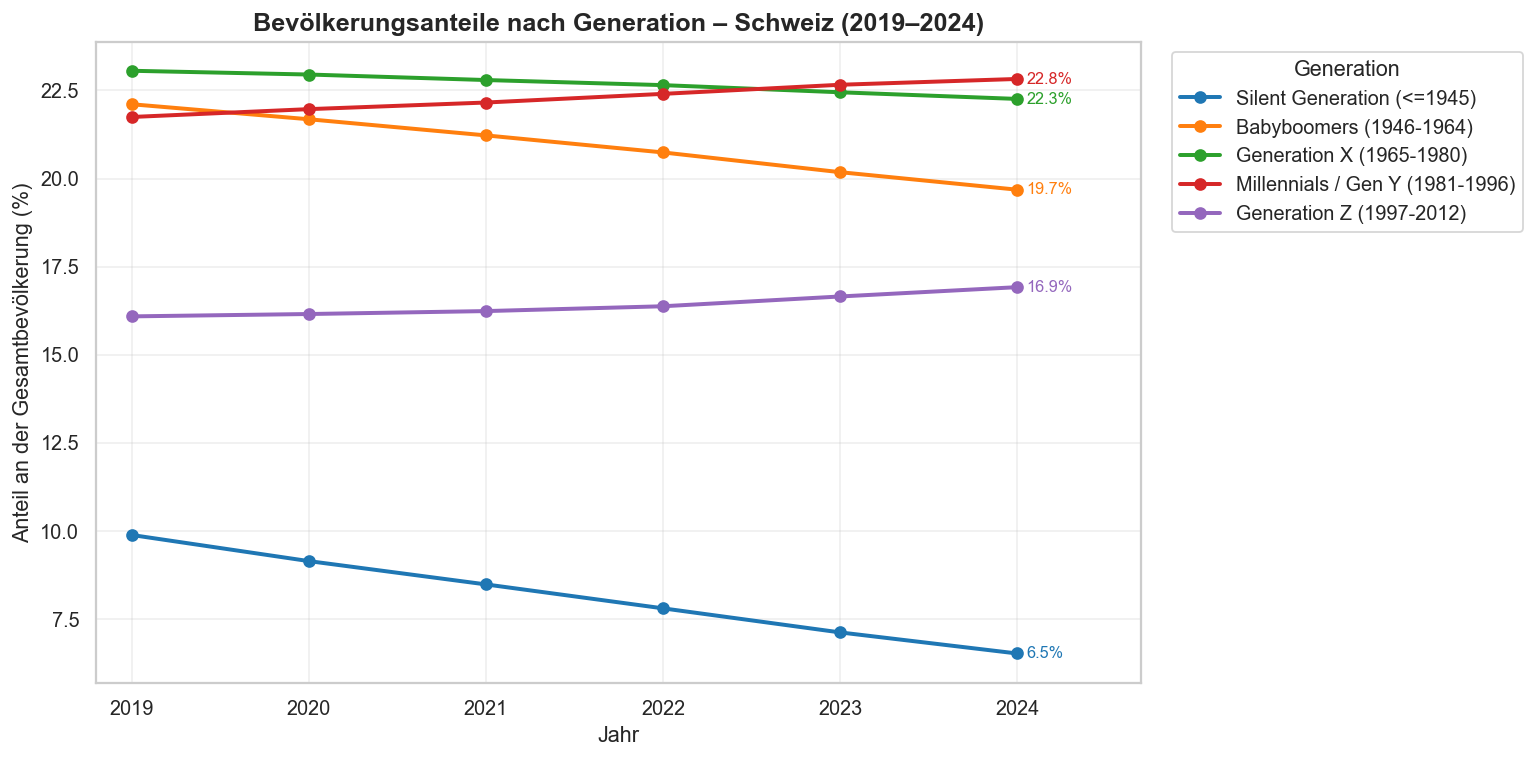


Veränderung der Generationsanteile 2019 → 2024:
year                              2019   2024  Δ (PP)
generation_label                                     
Silent Generation (<=1945)        9.88   6.52   -3.36
Babyboomers (1946-1964)          22.11  19.68   -2.43
Generation X (1965-1980)         23.06  22.26   -0.80
Millennials / Gen Y (1981-1996)  21.75  22.83    1.08
Generation Z (1997-2012)         16.09  16.92    0.83


In [23]:
# ── Aggregation ────────────────────────────────────────────────────────────────
schweiz = demo[
    demo[canton_col].astype(str).str.strip().str.lower() == "schweiz"
].copy()

gen_year = (
    schweiz
    .groupby(["year", "generation_label"], observed=False)["population"]
    .sum()
    .reset_index()
)
gen_year["share_pct"] = (
    gen_year.groupby("year")["population"]
    .transform(lambda s: s / s.sum() * 100 if s.sum() > 0 else 0)
)
gen_year = gen_year[gen_year["generation_label"].isin(GEN_ORDER_PLOT)]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for gen in GEN_ORDER_PLOT:
    sub = gen_year[gen_year["generation_label"] == gen].sort_values("year")
    if sub.empty:
        continue
    color = GEN_PALETTE[gen]
    ax.plot(sub["year"], sub["share_pct"], marker="o", linewidth=2.2, color=color, label=gen)
    last = sub.iloc[-1]
    ax.annotate(f"{last['share_pct']:.1f}%", xy=(last["year"], last["share_pct"]),
                xytext=(5, 0), textcoords="offset points", va="center", fontsize=9, color=color)

years_all = sorted(gen_year["year"].unique())
ax.set_xticks(years_all)
ax.set_xlim(years_all[0] - 0.2, years_all[-1] + 0.7)
ax.set_title("Bevölkerungsanteile nach Generation – Schweiz (2019–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Jahr", fontsize=12)
ax.set_ylabel("Anteil an der Gesamtbevölkerung (%)", fontsize=12)
ax.legend(title="Generation", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Vergleichstabelle ──────────────────────────────────────────────────────────
pivot = (
    gen_year[gen_year["year"].isin([2019, 2024])]
    .pivot(index="generation_label", columns="year", values="share_pct")
)
pivot["Δ (PP)"] = pivot[2024] - pivot[2019]
print("\nVeränderung der Generationsanteile 2019 → 2024:")
print(pivot.round(2).to_string())


## Analyse 2 – Bevölkerung nach Kanton (Heatmap)

Zürich, Bern und Waadt machen zusammen ~40% der Schweizer Bevölkerung aus. Diese Grössenunterschiede sind beim Lesen kantonaler Eigentumsquoten zu beachten.


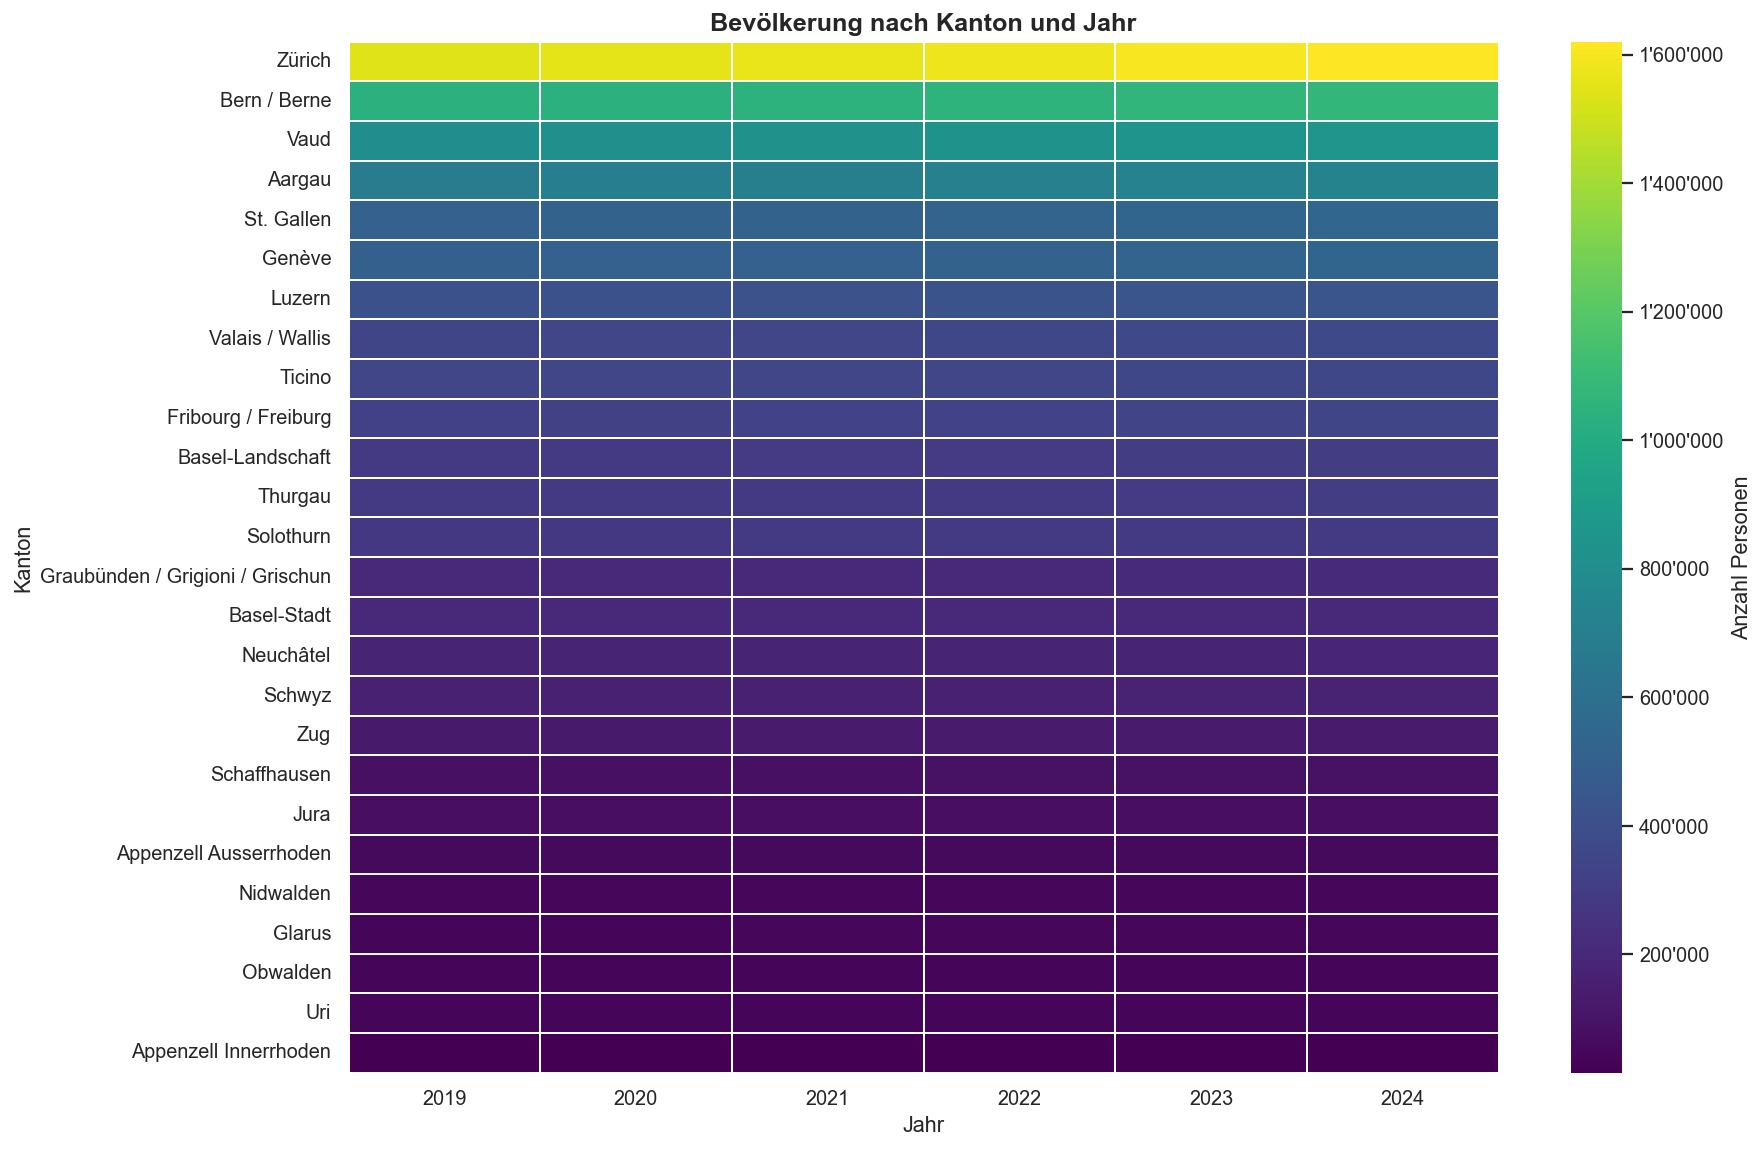

In [24]:
kanton_year = (
    demo[~demo[canton_col].astype(str).str.strip().str.lower().isin(["schweiz", "ohne angabe"])]
    .groupby([canton_col, "year"], as_index=False)["population"]
    .sum()
)

kanton_order = (
    kanton_year.groupby(canton_col)["population"]
    .sum().sort_values(ascending=False).index.tolist()
)
heatmap_data = (
    kanton_year
    .pivot(index=canton_col, columns="year", values="population")
    .reindex(kanton_order)
)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    heatmap_data, ax=ax, cmap="viridis",
    linewidths=0.2, linecolor="white",
    cbar_kws={"label": "Anzahl Personen"},
    fmt=".0f"
)
# Tausendertrennzeichen auf Colorbar
ax.collections[0].colorbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "'"))
)
ax.set_title("Bevölkerung nach Kanton und Jahr", fontsize=14, fontweight="bold")
ax.set_xlabel("Jahr", fontsize=12)
ax.set_ylabel("Kanton", fontsize=12)
plt.tight_layout()
plt.show()


## Analyse 3 – Wohneigentumsquote nach Kanton

Klarer **Stadt-Land-Gradient**: Genf ~18% vs. Uri/Appenzell >55%.  
Die Referenzlinie zeigt den ungewichteten Schweizer Durchschnitt über alle verfügbaren Jahre.


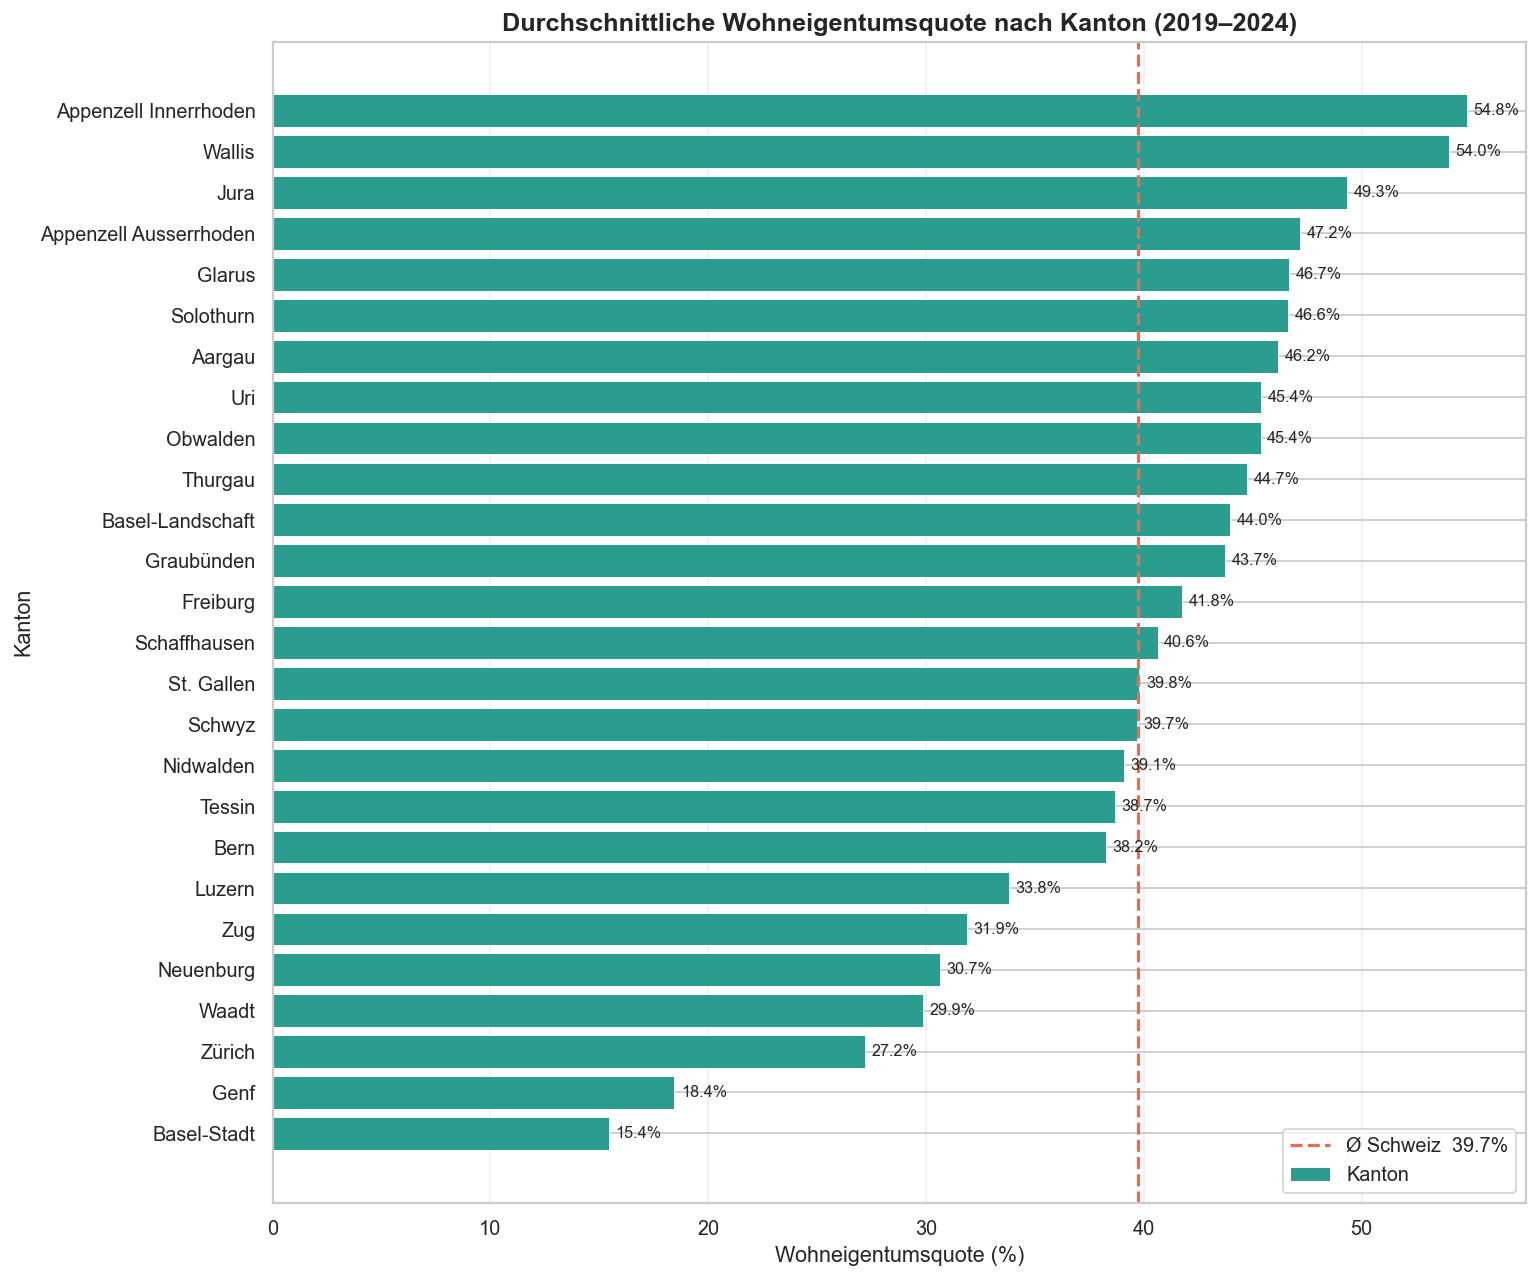

  Min: 15.4%  (Basel-Stadt)
  Max: 54.8%  (Appenzell Innerrhoden)


C:\Users\jmart\AppData\Local\Temp\ipykernel_38868\1573419754.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (


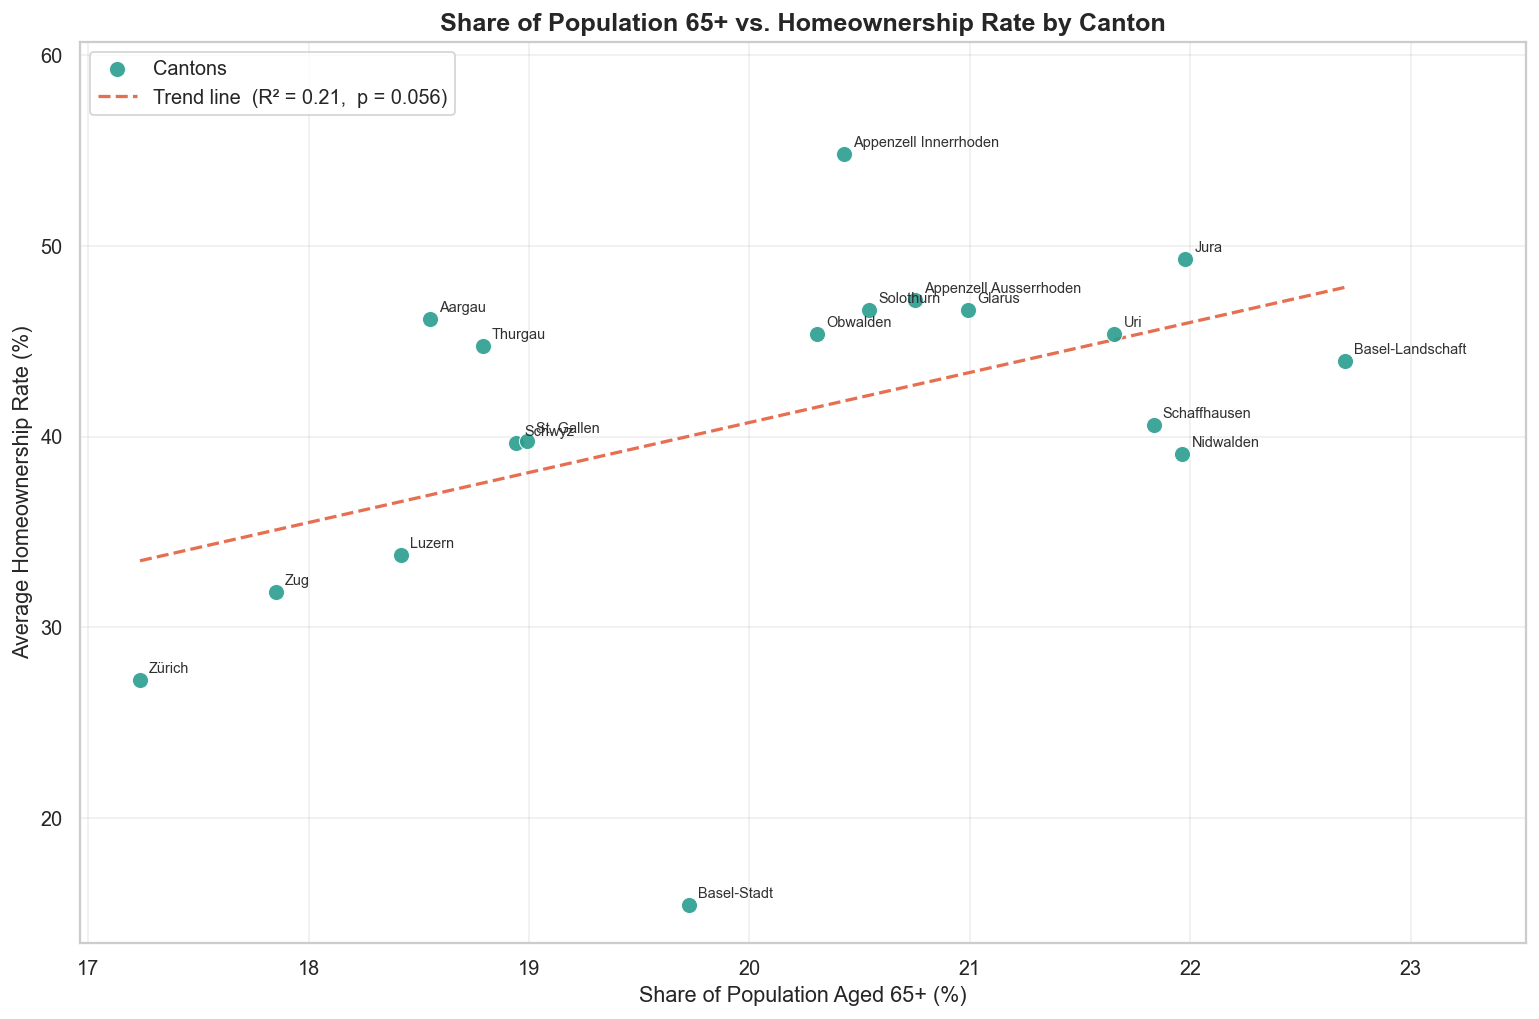

Pearson r = 0.458  |  R² = 0.210  |  p = 0.0561
→ Not significant

Top 10 cantons by homeownership rate:
                canton  homeownership_pct  pct_65plus
 Appenzell Innerrhoden              54.82       20.43
                  Jura              49.32       21.98
Appenzell Ausserrhoden              47.18       20.75
                Glarus              46.67       20.99
             Solothurn              46.63       20.54
                Aargau              46.17       18.55
                   Uri              45.40       21.66
              Obwalden              45.37       20.31
               Thurgau              44.73       18.79
      Basel-Landschaft              43.97       22.70


In [25]:
ranking = (
    we_kantone.groupby("label_de")["obs_value"]
    .mean().sort_values(ascending=True).reset_index()
)
ch_avg = ranking["obs_value"].mean()

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(ranking["label_de"], ranking["obs_value"],
               color="#2a9d8f", edgecolor="white", linewidth=0.5, label="Kanton")
ax.axvline(ch_avg, color="#e76f51", linestyle="--", linewidth=1.8,
           label=f"Ø Schweiz  {ch_avg:.1f}%")

for bar, val in zip(bars, ranking["obs_value"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_title("Durchschnittliche Wohneigentumsquote nach Kanton (2019–2024)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Wohneigentumsquote (%)", fontsize=12)
ax.set_ylabel("Kanton", fontsize=12)
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"  Min: {ranking['obs_value'].min():.1f}%  ({ranking.iloc[0]['label_de']})")
print(f"  Max: {ranking['obs_value'].max():.1f}%  ({ranking.iloc[-1]['label_de']})")

# ── Vergleich: Durchschnittsalter vs. Wohneigentumsquote nach Kanton ───────────
from scipy import stats

# ── Anteil 65+ pro Kanton (bevölkerungsgewichtet, alle Jahre gemittelt) ────────
demo_kantone = (
    demo[~demo[canton_col].astype(str).str.strip().str.lower().isin(["schweiz", "ohne angabe"])]
    .dropna(subset=["age_num", "population", canton_col])
    .copy()
)

age65_by_canton = (
    demo_kantone
    .groupby(canton_col)
    .apply(lambda g: (
        g.loc[g["age_num"] >= 65, "population"].sum() /
        g["population"].sum() * 100
    ))
    .reset_index(name="pct_65plus")
    .rename(columns={canton_col: "canton"})
)

comparison = (
    ranking
    .rename(columns={"label_de": "canton", "obs_value": "homeownership_pct"})
    .merge(age65_by_canton, on="canton", how="inner")
)

# ── Statistik ──────────────────────────────────────────────────────────────────
r, p = stats.pearsonr(comparison["pct_65plus"], comparison["homeownership_pct"])
slope, intercept, *_ = stats.linregress(comparison["pct_65plus"], comparison["homeownership_pct"])
r_sq = r ** 2

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    comparison["pct_65plus"], comparison["homeownership_pct"],
    color="#2a9d8f", edgecolor="white", linewidth=0.6,
    s=80, alpha=0.9, zorder=3, label="Cantons"
)

x_line = np.linspace(comparison["pct_65plus"].min(), comparison["pct_65plus"].max(), 100)
ax.plot(
    x_line, slope * x_line + intercept,
    color="#e76f51", linestyle="--", linewidth=1.8,
    label=f"Trend line  (R² = {r_sq:.2f},  p = {p:.3f})"
)

try:
    from adjustText import adjust_text
    texts = [
        ax.text(r["pct_65plus"], r["homeownership_pct"], r["canton"], fontsize=8)
        for _, r in comparison.iterrows()
    ]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
except ImportError:
    for _, r in comparison.iterrows():
        ax.annotate(r["canton"], (r["pct_65plus"], r["homeownership_pct"]),
                    xytext=(5, 4), textcoords="offset points", fontsize=8, alpha=0.95)

x_pad = (comparison["pct_65plus"].max() - comparison["pct_65plus"].min()) * 0.05
y_pad = (comparison["homeownership_pct"].max() - comparison["homeownership_pct"].min()) * 0.05
ax.set_xlim(comparison["pct_65plus"].min() - x_pad, comparison["pct_65plus"].max() + x_pad * 3)
ax.set_ylim(comparison["homeownership_pct"].min() - y_pad, comparison["homeownership_pct"].max() + y_pad * 3)

ax.set_title("Share of Population 65+ vs. Homeownership Rate by Canton",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Share of Population Aged 65+ (%)", fontsize=12)
ax.set_ylabel("Average Homeownership Rate (%)", fontsize=12)
ax.legend(loc="upper left", frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pearson_r = comparison["pct_65plus"].corr(comparison["homeownership_pct"])
print(f"Pearson r = {pearson_r:.3f}  |  R² = {r_sq:.3f}  |  p = {p:.4f}")
print(f"→ {'Significant (p < 0.05)' if p < 0.05 else 'Not significant'}")
print("\nTop 10 cantons by homeownership rate:")
print(comparison.sort_values("homeownership_pct", ascending=False).head(10).round(2).to_string(index=False))

## Interpretation: Share of Population 65+ vs. Homeownership Rate

The scatter plot compares the **share of residents aged 65 and older** with the
**average cantonal homeownership rate** (2019–2024).

### Findings

A positive correlation (Pearson r ≈ 0.210) indicates that cantons with a
higher share of older residents tend to have higher homeownership rates. This is
consistent with the central hypothesis of this EDA: older generations —
particularly the Silent Generation and Babyboomers — accumulated residential
property over their lifetimes at a time when purchase prices and equity
requirements were substantially lower than today.

### Why 65+ share instead of average age?

Average age compresses the full age distribution into a single number: two cantons
can share the same average age but differ substantially in the proportion of older
residents. The 65+ share directly captures the population segment corresponding to
the Silent Generation and Babyboomers — the generations most likely to be
homeowners — and therefore aligns more closely with the research question.

### Methodological limitation: ecological fallacy

This analysis operates at the **cantonal level**, not the individual level.
A positive correlation between the 65+ share and the homeownership rate does **not**
prove that older individuals within a canton are more likely to own property.
The observed pattern may be partly explained by confounding variables:

- Rural cantons tend to have both older populations and lower property prices,
  making ownership more accessible regardless of age.
- Urban cantons (Geneva, Basel-Stadt) attract younger, mobile populations and have
  structurally low homeownership rates driven by high land prices.

This limitation should be kept in mind when interpreting the correlation as evidence
for the generational hypothesis. Ideally, individual-level microdata linking age and
tenure status would be required to establish a causal relationship.

## Analyse 4 – Bewohnertyp nach Generation (2019–2024)

**Plot A** – 100%-gestapelte Balken pro Jahr: Wohnformverteilung innerhalb jeder Generation.  
**Plot B** – Liniendiagramm: Entwicklung des Eigentümeranteils über die Zeit.

Ältere Generationen dominieren bei Wohneigentum; Millennials & Gen Z sind überwiegend Mieter.


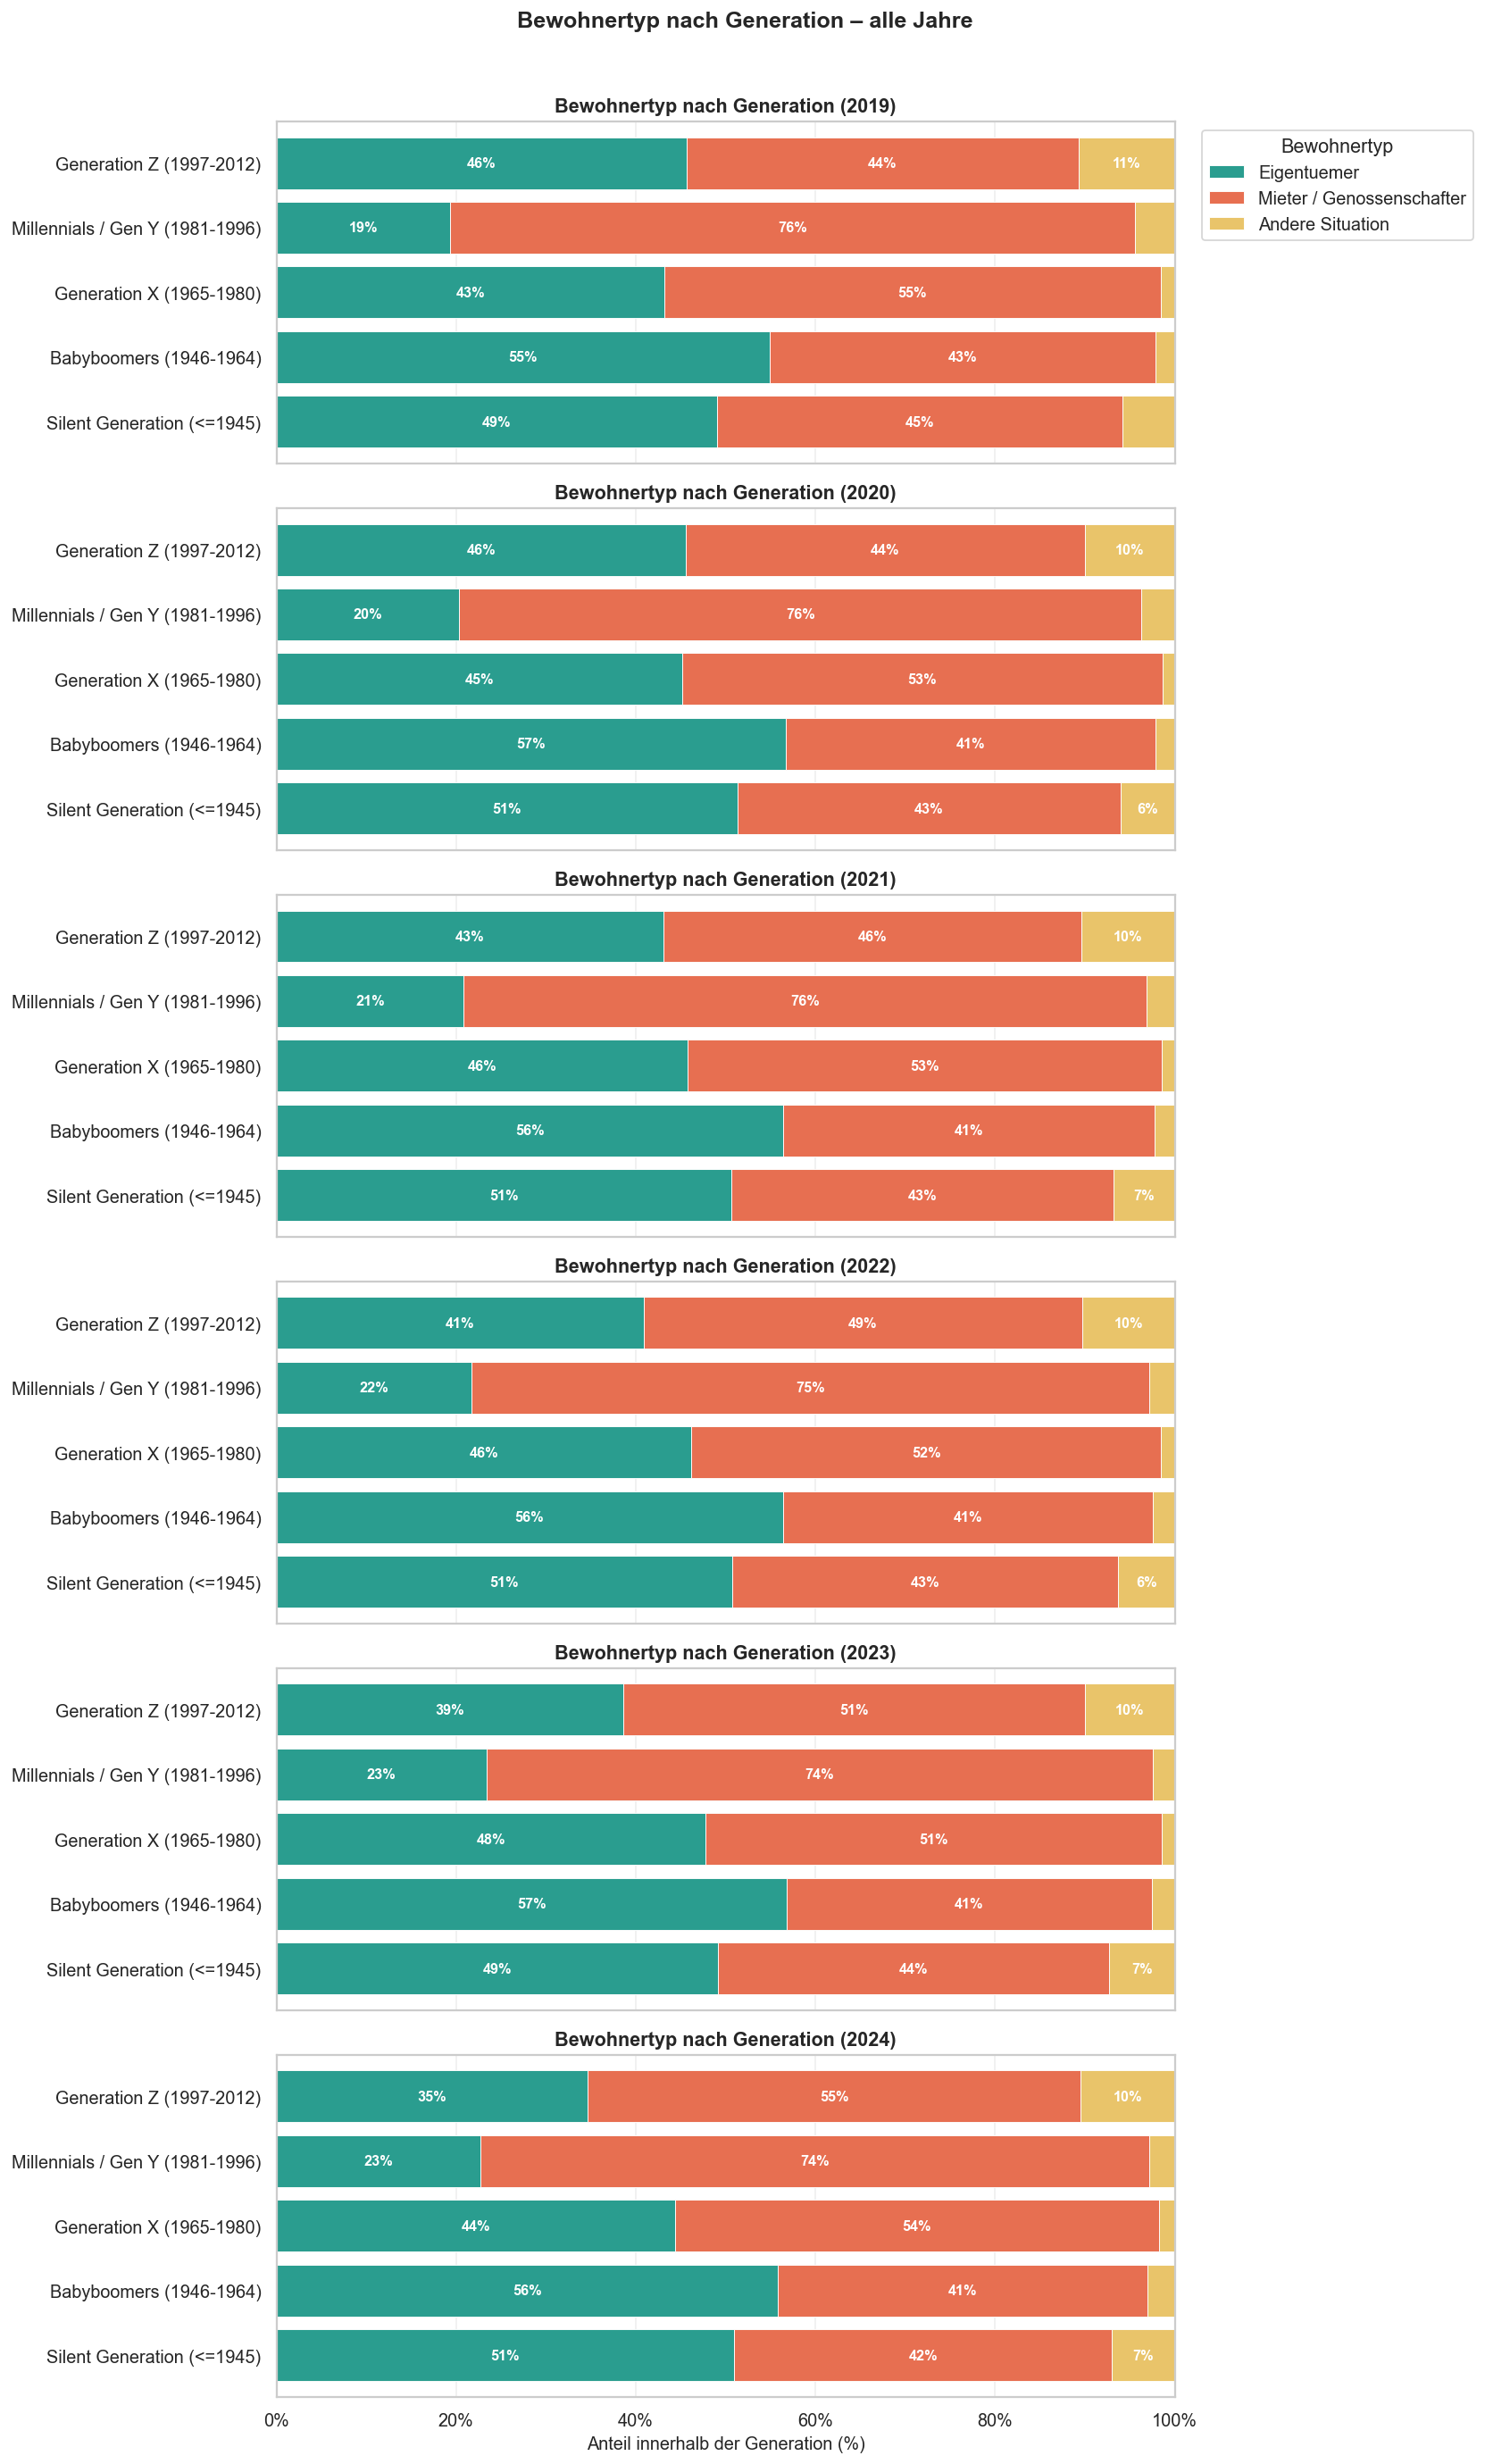

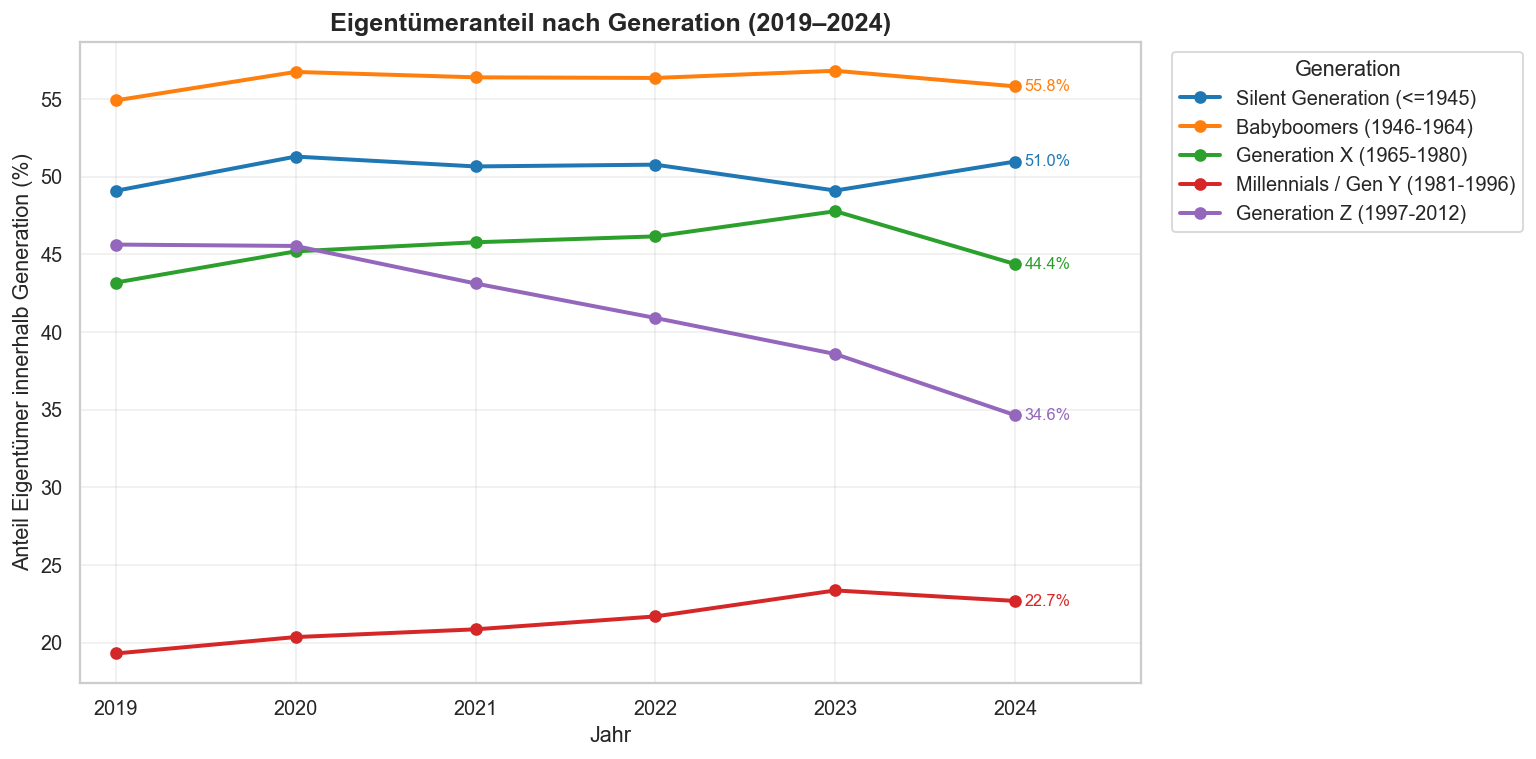

In [26]:
# ── Aggregation ────────────────────────────────────────────────────────────────
bt_base = (
    bewohnertyp
    .query("bt_label != 'total' and generation_label in @GEN_ORDER_PLOT")
    [["time_period", "generation_label", "bt_label", bt_val_col]]
    .dropna()
    .copy()
)
bt_base = bt_base[bt_base["bt_label"].isin(BT_PALETTE.keys())].copy()
bt_base["time_period"] = bt_base["time_period"].astype(int)

# ── Plot A: 100%-gestapelte Balken (ein Subplot pro Jahr) ─────────────────────
years = sorted(bt_base["time_period"].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(13, 3.5 * len(years)), sharex=True)

for ax, year in zip(np.atleast_1d(axes), years):
    agg = (
        bt_base[bt_base["time_period"] == year]
        .groupby(["generation_label", "bt_label"], observed=True)[bt_val_col]
        .sum().reset_index()
    )
    agg["share"] = agg.groupby("generation_label", observed=True)[bt_val_col].transform(
        lambda s: s / s.sum() * 100 if s.sum() > 0 else 0
    )
    pivot = (
        agg.pivot(index="generation_label", columns="bt_label", values="share")
        .reindex(GEN_ORDER_PLOT)
        .fillna(0)
        .reindex(columns=list(BT_PALETTE.keys()), fill_value=0)
    )
    # Sicherstellen, dass jede Generation exakt auf 100% skaliert ist.
    row_sum = pivot.sum(axis=1)
    pivot = pivot.div(row_sum.where(row_sum > 0, 1), axis=0) * 100

    left = np.zeros(len(pivot))
    for col in pivot.columns:
        vals = pivot[col].to_numpy()
        ax.barh(pivot.index.astype(str), vals, left=left,
                color=BT_PALETTE[col], edgecolor="white", linewidth=0.5, label=col)
        for i, v in enumerate(vals):
            if v > 6:
                ax.text(left[i] + v / 2, i, f"{v:.0f}%",
                        va="center", ha="center", fontsize=9,
                        color="white", fontweight="bold")
        left += vals

    ax.set_title(f"Bewohnertyp nach Generation ({year})", fontsize=12, fontweight="bold")
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.grid(True, axis="x", alpha=0.3)

np.atleast_1d(axes)[0].legend(title="Bewohnertyp", bbox_to_anchor=(1.02, 1), loc="upper left")
np.atleast_1d(axes)[-1].set_xlabel("Anteil innerhalb der Generation (%)", fontsize=11)
plt.suptitle("Bewohnertyp nach Generation – alle Jahre", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Plot B: Eigentümeranteil über Zeit ─────────────────────────────────────────
yearly = (
    bt_base
    .groupby(["time_period", "generation_label", "bt_label"], observed=True)[bt_val_col]
    .sum().reset_index()
)
yearly["share"] = yearly.groupby(["time_period", "generation_label"], observed=True)[bt_val_col].transform(
    lambda s: s / s.sum() * 100 if s.sum() > 0 else 0
)
eigentuemer = yearly[yearly["bt_label"] == "Eigentuemer"]

fig, ax = plt.subplots(figsize=(12, 6))
for gen in GEN_ORDER_PLOT:
    sub = eigentuemer[eigentuemer["generation_label"] == gen].sort_values("time_period")
    if sub.empty:
        continue
    color = GEN_PALETTE[gen]
    ax.plot(sub["time_period"], sub["share"], marker="o", linewidth=2.2, color=color, label=gen)
    last = sub.iloc[-1]
    ax.annotate(f"{last['share']:.1f}%", xy=(last["time_period"], last["share"]),
                xytext=(5, 0), textcoords="offset points", va="center", fontsize=9, color=color)

years_all = sorted(eigentuemer["time_period"].unique())
ax.set_xticks(years_all)
ax.set_xlim(years_all[0] - 0.2, years_all[-1] + 0.7)
ax.set_title("Eigentümeranteil nach Generation (2019–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Jahr", fontsize=12)
ax.set_ylabel("Anteil Eigentümer innerhalb Generation (%)", fontsize=12)
ax.legend(title="Generation", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Analyse 5 – Wohnfläche pro Person nach Generation (2019–2024)

**Linienplot mit 95%-Konfidenzband** (basierend auf SEM, nicht Standardabweichung).

**Erwartetes Muster:** Silent Generation >60 m², Gen Z ~30 m² – zwei Erklärungen:  
1. *Eigentümereffekt*: Eigentümer (ältere Gen.) bewohnen grössere Wohnungen  
2. *Empty-Nest-Effekt*: Ältere Menschen wohnen oft allein in ehemals familiengrossen Wohnungen


C:\Users\jmart\AppData\Local\Temp\ipykernel_38868\2110491363.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_wf.groupby(["year", "generation_label"])[wf_area_col]


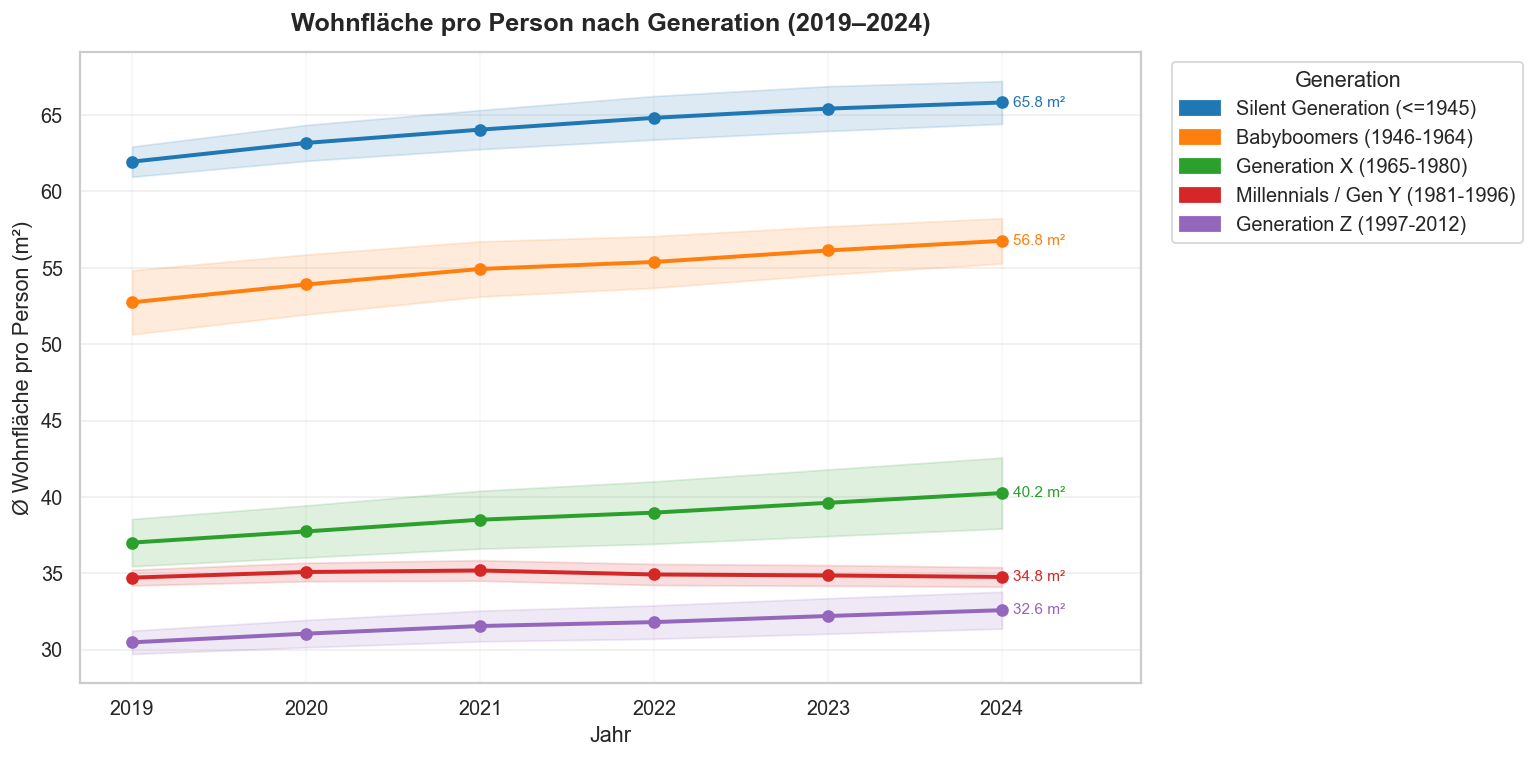

In [ ]:
# ── Daten ──────────────────────────────────────────────────────────────────────
df_wf = (
    wohnflaeche
    .query("generation_label in @GEN_ORDER_PLOT")
    [["time_period", "generation_label", wf_area_col]]
    .dropna()
    .assign(year=lambda x: pd.to_numeric(x["time_period"], errors="coerce").astype("Int64"))
    .dropna(subset=["year"])
)

# Mittelwert + 95%-Konfidenzintervall (SEM-basiert)
stats_wf = (
    df_wf.groupby(["year", "generation_label"])[wf_area_col]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
    .assign(
        ci95 = lambda x: 1.96 * x["std"] / np.sqrt(x["n"]),
        lo   = lambda x: x["mean"] - 1.96 * x["std"] / np.sqrt(x["n"]),
        hi   = lambda x: x["mean"] + 1.96 * x["std"] / np.sqrt(x["n"]),
    )
)
stats_wf["generation_label"] = pd.Categorical(stats_wf["generation_label"], categories=GEN_ORDER_PLOT, ordered=True)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for gen in GEN_ORDER_PLOT:
    sub = stats_wf[stats_wf["generation_label"] == gen].sort_values("year")
    if sub.empty:
        continue
    color = GEN_PALETTE[gen]
    ax.plot(sub["year"], sub["mean"], marker="o", linewidth=2.2,
            markersize=6, color=color, label=gen, zorder=3)
    ax.fill_between(sub["year"], sub["lo"], sub["hi"],
                    color=color, alpha=0.15, zorder=2)
    last = sub.iloc[-1]
    ax.annotate(f"{last['mean']:.1f} m²", xy=(last["year"], last["mean"]),
                xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=color)

years_all = sorted(stats_wf["year"].dropna().unique())
ax.set_xticks(years_all)
ax.set_xlim(min(years_all) - 0.3, max(years_all) + 0.8)
ax.set_title("Wohnfläche pro Person nach Generation (2019–2024)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Jahr", fontsize=12)
ax.set_ylabel("Ø Wohnfläche pro Person (m²)", fontsize=12)
ax.grid(True, axis="y", alpha=0.3)
ax.grid(True, axis="x", alpha=0.15)

handles = [mpatches.Patch(color=GEN_PALETTE[g], label=g)
           for g in GEN_ORDER_PLOT if g in stats_wf["generation_label"].values]
ax.legend(handles=handles, title="Generation", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Zusammenfassung der EDA-Erkenntnisse

| Fragestellung | Befund |
|---|---|
| Generationsverteilung Schweiz | Babyboomers dominieren numerisch; Silent Generation schrumpft; Gen Z wächst langsam |
| Kantonale Eigentumsquote | Klarer Stadt-Land-Gradient: Genf ~18%, Uri/Appenzell >55% |
| Bewohnertyp nach Generation | Ältere: überwiegend Eigentümer; Jüngere: überwiegend Mieter |
| Wohnfläche pro Person | Klarer Altersanstieg: Silent Gen >60 m², Gen Z ~30 m² |
| Eigentum & Alter (Kanton) | Positiver Zusammenhang – ländlich/alte Kantone mit höherer Quote |

**Narrativer Bogen:** Babyboomers und Silent Generation haben aufgebaut – Millennials und Gen Z zahlen Miete.
